In [7]:
#import the necessary packages for all analysis
import pandas as pd
import numpy as np 

In [8]:
#Import the data from Kaggle 
test_df = pd.read_csv('/Users/alextoy/Desktop/Kaggle Competitions /Titanic/titanic/test.csv')
train_df = pd.read_csv('/Users/alextoy/Desktop/Kaggle Competitions /Titanic/titanic/train.csv')

# Titanic Machine Learning - Logit 

In [9]:
#now import the sklearn packages for splitting the sample and for running the Logit analysis 
#for splitting test/train and for k-folds cross validation 
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate 

#to make transforming the data easier ColumnTransformer and Pipeline keep preprocessed data inside the folds 
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#for encoding the data 
from sklearn.impute import SimpleImputer 
from sklearn.preprocessing import OneHotEncoder, StandardScaler

#to actually run the model 
from sklearn.linear_model import LogisticRegression 

#to test how well the model performs 
from sklearn.metrics import log_loss, roc_auc_score, accuracy_score 


In [10]:
train_df.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [11]:
# with a simple test train split run a regression of survival on Pclass, Sex, Age, SibSp, Parch 
#first define the features we want to include in the model 
features = ['Pclass', 'Age','Sex','SibSp','Parch']
#next define what we want to predict as our target 
target = 'Survived'

#define what we're working on 
X = train_df[features]
y = train_df[target]


# SPLIT THE DATA
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.2, random_state = 1234, stratify = y) 

# Process the data 
# First split into continuous and categorical variables. 
numeric_features = ['Age','SibSp','Parch']
categorical_features = ['Pclass', 'Sex']
# Deal with missingness, and scale for continuous variables. 
# here i do mean imputation but also include a dummy for missingness
numeric_transformer = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy = "mean", add_indicator = True)),
     ("scaler", StandardScaler())])

# Deal with missingness and encoding for categorical variables
categorical_transformer = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy = 'constant', fill_value = "Missing")),
     ("onehot", OneHotEncoder(handle_unknown = "ignore"))])

#now preprocess the data 
preprocess = ColumnTransformer(transformers = [("num", numeric_transformer, numeric_features),
                                              ("cat", categorical_transformer, categorical_features)])


In [12]:
#now that we have the data cleaning process defined we can run the model. 
#Define what model we want to use 
model = LogisticRegression()

#now define the classifier 
clf = Pipeline(steps = [("preprocess", preprocess), ("model", model)])

#now fit the model to the training data
clf.fit(X_train, y_train)

#assign outcomes based on predicted probabilities
value_probability = clf.predict_proba(X_val)[:,1] 
#predict_proba gives the predicted probabilities for 0 and 1, so we take the second column because 1 is survival
#now we assign the value of 1 to any probability over 0.5
value_predicted = (value_probability > 0.5).astype(int)

In [13]:
#next we can evaluate model fit: 
#value_predicted = predictions
#value_probability = probability of survival 
#y_val = validation outcome (test true value)

#log loss (difference between predicted probability and observed binary outcome) 
print("Log Loss for Simple Logit:", log_loss(y_val, value_probability)) 

# ROC-AUC Score measures the models ability to distinguish between positives (1) and negative classes (0)
# if ROC-AUC = 0.5 this is pure guessing, if ROC-AUC = 1 this is perfect 
print("ROC-AUC Score for Simple Logit:", roc_auc_score(y_val, value_probability)) 

# Accuracy score is just the fraction of predictions that i got right. 
print("Accuracy Score for the Simple Logit:", accuracy_score(y_val, value_predicted))

Log Loss for Simple Logit: 0.4599904818734539
ROC-AUC Score for Simple Logit: 0.8513175230566535
Accuracy Score for the Simple Logit: 0.7821229050279329


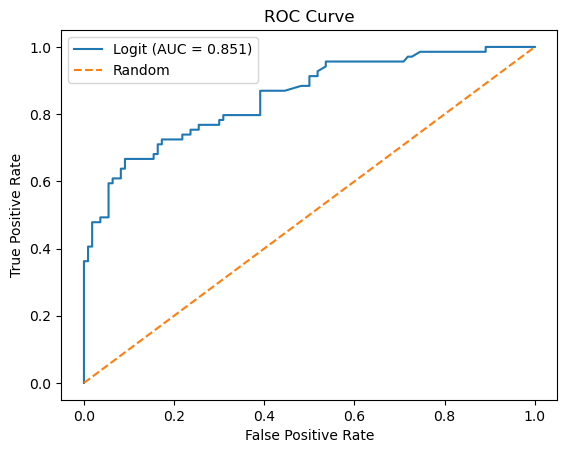

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
# Plot the ROC Curve for the simple logit model 
fpr, tpr, thresholds = roc_curve(y_val, value_probability)
auc = roc_auc_score(y_val, value_probability)

plt.figure()
plt.plot(fpr, tpr, label=f"Logit (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [15]:
#Now instead of doing a standard test train split do k-fold cross validation. 
# K permutations of test and train sample. 
# Number of folds 
k = 5

#cross validation 
cv = StratifiedKFold(n_splits = k, shuffle = True, random_state = 1234) 

#Now get the model performance metrics we want to track and put them in a Dict 
scoring = {
    'logloss': 'neg_log_loss',
    'roc_auc': 'roc_auc',
    'accuracy': 'accuracy'}

#now run the cross validation 
cv_results = cross_validate(
    clf, X, y, 
    cv = cv, 
    scoring = scoring, 
    return_train_score = False 
)

#now get the measures for our 5 cross validations (convert neg log loss to positive as well)
logloss = -cv_results["test_logloss"]
roc_auc = cv_results["test_roc_auc"]
acc = cv_results["test_accuracy"]

print(f"{k}-fold CV Log Loss: {logloss.mean():.4f} ± {logloss.std():.4f}")
print(f"{k}-fold CV ROC-AUC:  {roc_auc.mean():.4f} ± {roc_auc.std():.4f}")
print(f"{k}-fold CV Accuracy: {acc.mean():.4f} ± {acc.std():.4f}")

5-fold CV Log Loss: 0.4491 ± 0.0285
5-fold CV ROC-AUC:  0.8535 ± 0.0188
5-fold CV Accuracy: 0.7913 ± 0.0259


In [21]:
# Next we want to see the coefficients in a table like a regression output 
import statsmodels.api as sm

#First we want to fit the model only on the training data 
pre = clf.named_steps["preprocess"]

X_train_sm = pre.fit_transform(X_train)
X_val_sm = pre.transform(X_val)

# now get the feature names 
feature_names = pre.get_feature_names_out()

# Turn it into a dataframe 
X_train_sm_df = pd.DataFrame(X_train_sm, columns = feature_names, index = X_train.index)

# Add the intercept 
X_train_sm_df = sm.add_constant(X_train_sm_df, has_constant = 'add')

# fit the statsmodels logit regression 
logit_sm = sm.Logit(y_train, X_train_sm_df[['const','num__Age', 'num__SibSp', 'num__Parch','num__missingindicator_Age','cat__Pclass_2','cat__Pclass_3','cat__Sex_male']])
res = logit_sm.fit(disp = False)

#look at the summary 
print(res.summary())


                           Logit Regression Results                           
Dep. Variable:               Survived   No. Observations:                  712
Model:                          Logit   Df Residuals:                      704
Method:                           MLE   Df Model:                            7
Date:                Fri, 27 Feb 2026   Pseudo R-squ.:                  0.3397
Time:                        09:36:49   Log-Likelihood:                -313.00
converged:                       True   LL-Null:                       -473.99
Covariance Type:            nonrobust   LLR p-value:                 1.215e-65
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                         2.7133      0.271      9.995      0.000       2.181       3.245
num__Age                     -0.5358      0.114     -4.700      0.000      -0.759     

In [22]:
#now we want to look at the predictive power of each of our covariates. 
#for this we'll look at permutation importance which shuffles features and see if performance gets worse. 
from sklearn.inspection import permutation_importance 

#fit the model like normal 
clf.fit(X_train, y_train)

# Then run importance on the validation set and choose what metric you want to score by 
r = permutation_importance(
    clf, X_val, y_val, 
    n_repeats = 30, 
    random_state = 1234,
    scoring = "roc_auc")

#now put the results in a dataframe for ease of understanding
imp = pd.DataFrame({"feature":features, 
                    "importance mean": r.importances_mean, 
                    "importance std": r.importances_std}).sort_values("importance mean", ascending = False)

print(imp)

  feature  importance mean  importance std
2     Sex         0.242697        0.033741
0  Pclass         0.080228        0.018997
1     Age         0.042016        0.011371
3   SibSp         0.015288        0.009072
4   Parch         0.001221        0.003240
